In [1]:
import ee
import pandas as pd
import openpyxl
import ee
import datetime
import os
from PIL import Image
import numpy as np
import json
import IPython.display as disp

In [2]:
import os
import json
import torch
import numpy as np
from PIL import Image
from skimage.io import imread
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split


In [3]:
from image_preprocessing import ImagePadder
from logger_utils import load_dict_from_json
import dataset

ModuleNotFoundError: No module named 'image_preprocessing'

In [ ]:
! cp "/content/drive/MyDrive/CIMA2023/Documentos2023/Proyectos/Proy1-ImagenesEspectrales/Code/Apis/oefa_cde_img_result.csv" "/content/"

In [7]:
# Set the paths to your dataset
TRAIN_PATH = '/content/drive/MyDrive/CIMA2023/Documentos2023/Proyectos/Proy1-ImagenesEspectrales/data/imagenes/OilDataset/train/images/'  # Replace with the path to your images directory
LABEL_PATH = '/content/drive/MyDrive/CIMA2023/Documentos2023/Proyectos/Proy1-ImagenesEspectrales/data/imagenes/OilDataset/train/labels_1D/'

In [ ]:
image_ids = [file for file in next(os.walk(TRAIN_PATH))[2] if file.endswith('.jpg') or file.endswith('.png')]
label_ids = [file for file in next(os.walk(LABEL_PATH))[2] if file.endswith('.png')]

In [6]:
TRAIN_PATH = '/content/drive/MyDrive/CIMA2023/Documentos2023/Proyectos/Proy1-ImagenesEspectrales/data/imagenes/OilDataset'

In [ ]:
df = dataset.get_dataloaders_for_training(TRAIN_PATH,16)

dataset information
number of train samples: 951
number of validation samples: 51


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [8]:
!cp "/content/drive/Othercomputers/MiPC/Code_OilSpill/training/train.py" "/content/"
!cp "/content/drive/Othercomputers/MiPC/Code_OilSpill/training/encoder_models.py" "/content/"
!cp "/content/drive/Othercomputers/MiPC/Code_OilSpill/training/decoder_models.py" "/content/"
!cp "/content/drive/Othercomputers/MiPC/Code_OilSpill/training/seg_models.py" "/content/"
!cp "/content/drive/Othercomputers/MiPC/Code_OilSpill/training/summarize_model.py" "/content/"
!cp "/content/drive/Othercomputers/MiPC/Code_OilSpill/training/dataset.py" "/content/"
!cp "/content/drive/Othercomputers/MiPC/Code_OilSpill/training/exploratory_data_analysis.py" "/content/"
!cp "/content/drive/Othercomputers/MiPC/Code_OilSpill/training/metrics.py" "/content/"
!cp "/content/drive/Othercomputers/MiPC/Code_OilSpill/training/image_preprocessing.py" "/content/"
!cp "/content/drive/Othercomputers/MiPC/Code_OilSpill/training/logger_utils.py" "/content/"
!cp "/content/drive/Othercomputers/MiPC/Code_OilSpill/training/image_stats.json" "/content/"

In [5]:
import exploratory_data_analysis as eda
from train import batch_train, main

Label files are read from the directory: /content/drive/MyDrive/CIMA2023/Documentos2023/Proyectos/Proy1-ImagenesEspectrales/data/imagenes/OilDataset/train/labels_1D
Number of label files : 1002
{0: 716886932, 1: 8192020, 2: 45832926, 3: 346855, 4: 42866267}


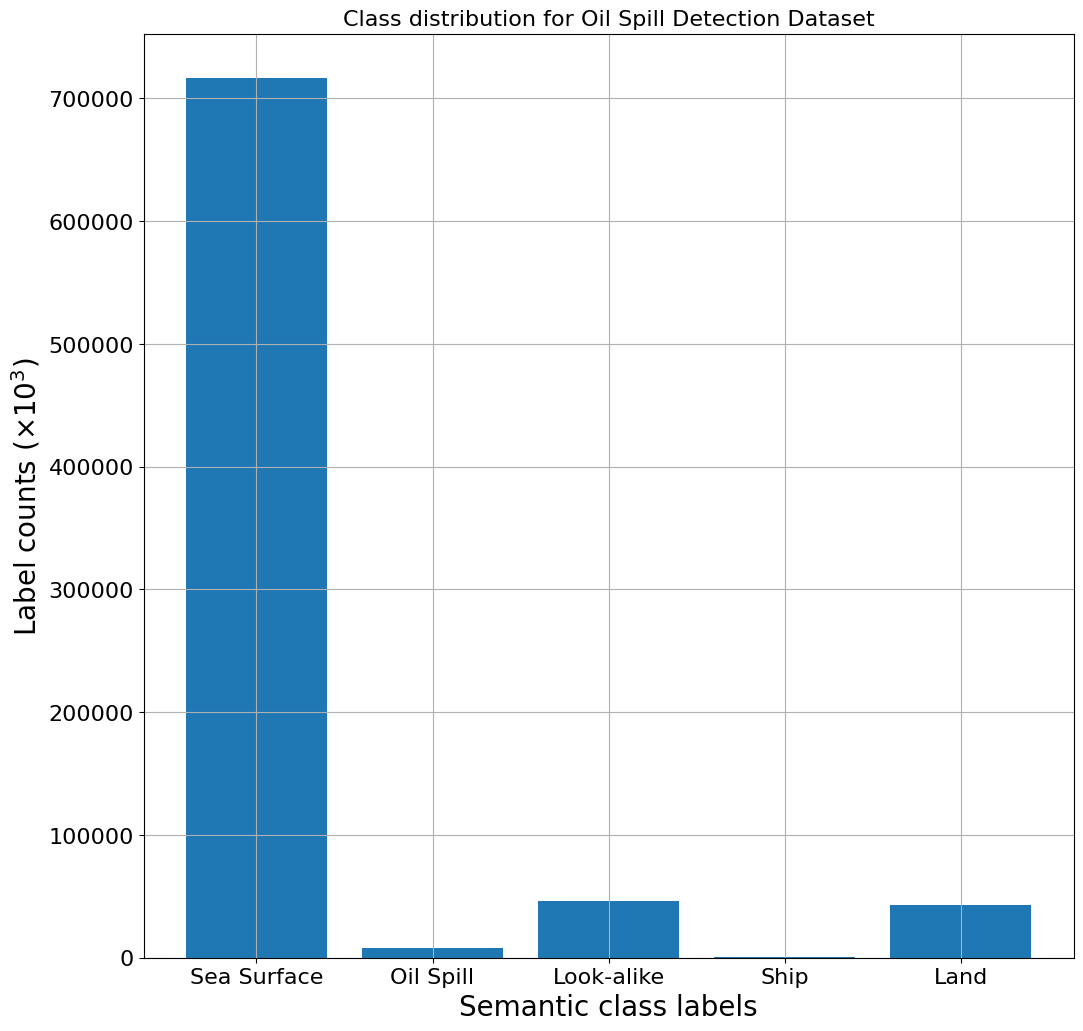

In [6]:
class SimpleNamespace:
    def __init__(self, **kwargs):
        self.__dict__.update(kwargs)

# Define the directory path
dir_labels = "/content/drive/MyDrive/CIMA2023/Documentos2023/Proyectos/Proy1-ImagenesEspectrales/data/imagenes/OilDataset/train/labels_1D/"

# Create a FLAGS-like object
FLAGS = SimpleNamespace(dir_labels=dir_labels)

# Call the function
eda.do_exploratory_data_analysis(FLAGS)

In [ ]:
# Assuming `train.py` contains the `batch_train()` function, you can import it like this:

from train import batch_train, main

# Call the function directly
main()

/content/resnet_18_deeplab_v3+/train_metrics.csv created successfully with header row
dataset information
number of train samples: 951
number of validation samples: 51


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]



training oil spill segmentation model: resnet_18_deeplab_v3+



In [13]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import transforms
from skimage.io import imread
import matplotlib.pyplot as plt

In [3]:
class ImagePadder:
    def __init__(
        self,
        dir_images,
        pad_left=15,
        pad_right=15,
        pad_top=11,
        pad_bottom=11,
        file_anchor_image="img_0814.jpg",
    ):
        self._anchor_image = imread(os.path.join(dir_images, file_anchor_image))
        self._anchor_image_shape = self._anchor_image.shape
        self._pad_left = pad_left
        self._pad_right = pad_right
        self._pad_top = pad_top
        self._pad_bottom = pad_bottom
        self._anchor_image_resized = None
        self._anchor_image_resized_shape = None

        self._set_anchor_image_resized()

    def _set_anchor_image_resized(self):
        height, width = self._anchor_image.shape[:2]
        target_width = self._pad_left + width + self._pad_right
        target_height = self._pad_top + height + self._pad_bottom
        self._anchor_image_resized = cv2.resize(
            self._anchor_image[:, 260:, :],
            (target_width, target_height),
            interpolation=cv2.INTER_LINEAR,
        )
        self._anchor_image_resized_shape = self._anchor_image_resized.shape

    def pad_image(self, image):
        padded_image = self._anchor_image_resized.copy()
        padded_image[
            self._pad_top : self._anchor_image_resized_shape[0] - self._pad_bottom,
            self._pad_left : self._anchor_image_resized_shape[1] - self._pad_right,
            :,
        ] = image
        return padded_image

    def pad_label(self, label):
        padded_label = np.pad(
            label,
            ((self._pad_top, self._pad_bottom), (self._pad_left, self._pad_right)),
        )
        return padded_label


In [19]:
class M4DSAROilSpillDataset(Dataset):
    def __init__(
        self,
        dir_data,
        list_images,
        which_set="train",
        file_stats_json="image_stats.json",
    ):
        self.dir_data = dir_data
        self.which_set = which_set
        self.file_stats_json = file_stats_json

        # Load image statistics (mean, std)
        self.dict_stats = self._load_stats()

        # Define paths for images and labels
        self._dir_images = os.path.join(self.dir_data, "images")
        self._dir_labels = os.path.join(self.dir_data, "labels_1D")

        # Sort images and labels
        self._list_images = sorted(list_images)
        self._list_labels = [f.replace(".jpg", ".png") for f in self._list_images]

        # Initialize ImagePadder
        self._image_padder = ImagePadder(
            dir_images=self._dir_images
        )

        # Define image transformations
        self._image_transform = transforms.Compose(
            [
                transforms.ToPILImage(),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[
                        self.dict_stats["mean"],
                        self.dict_stats["mean"],
                        self.dict_stats["mean"],
                    ],
                    std=[
                        self.dict_stats["std"],
                        self.dict_stats["std"],
                        self.dict_stats["std"],
                    ],
                ),
            ]
        )

        # Define augmentations for the training set
        if self.which_set == "train":
            self._affine_transform = transforms.Compose(
                [
                    transforms.RandomHorizontalFlip(),
                    transforms.RandomVerticalFlip(),
                ]
            )

    def _load_stats(self):
        return {"mean": 0.5185, "std": 0.197}

    def __len__(self):
        return len(self._list_images)

    def __getitem__(self, idx, return_original=False):
        file_image = os.path.join(self._dir_images, self._list_images[idx])
        file_label = os.path.join(self._dir_labels, self._list_labels[idx])

        image = imread(file_image)
        label = imread(file_label)

        original_image = image.copy()

        # Pad image and label
        image = self._image_padder.pad_image(image)
        label = self._image_padder.pad_label(label)

        if self.which_set == "train":
            image_tensor = torch.from_numpy(image)
            label_tensor = torch.from_numpy(label).unsqueeze(dim=-1)

            # Combine and apply augmentation
            stacked = torch.cat([image_tensor, label_tensor], dim=-1)
            stacked = torch.permute(stacked, [2, 0, 1])
            stacked_transformed = self._affine_transform(stacked)
            stacked_transformed = torch.permute(stacked_transformed, [1, 2, 0])
            stacked_arr = stacked_transformed.numpy()

            image = stacked_arr[:, :, :-1]
            label = stacked_arr[:, :, -1]

        # Apply normalization transform
        image = self._image_transform(image)

        if return_original:
            return image, label, original_image
        else:
            return image, label


In [21]:
# Set the paths to your dataset
dir_data = '/content/drive/MyDrive/CIMA2023/Documentos2023/Proyectos/Proy1-ImagenesEspectrales/data/imagenes/OilDataset/train/'
list_images = os.listdir(os.path.join(dir_data, "images"))

In [22]:
train_dataset = M4DSAROilSpillDataset(dir_data, list_images, which_set="train")

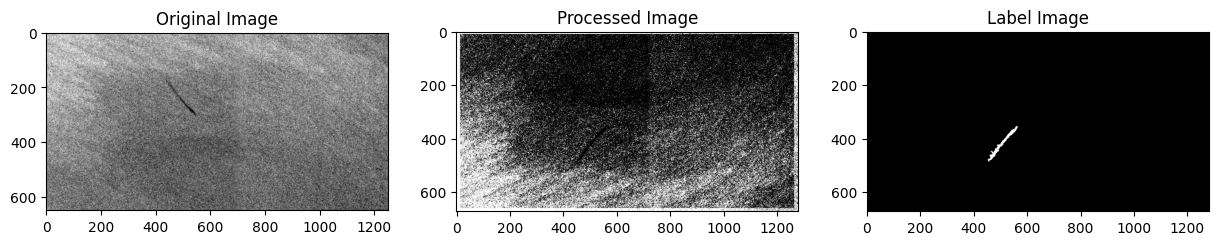

In [35]:
# Initialize the dataset
train_dataset = M4DSAROilSpillDataset(dir_data, list_images, which_set="train")

# Load a sample from the dataset, with the original image
image, label, original_image = train_dataset.__getitem__(0, return_original=True)

# Visualize the original image, processed image, and label
plt.figure(figsize=(15, 5))

# Display the original image
plt.subplot(1, 3, 1)
plt.imshow(original_image)
plt.title("Original Image")

# Display the processed image (tensor to numpy conversion and channel permutation)
plt.subplot(1, 3, 2)
plt.imshow(image.permute(1, 2, 0).numpy())
plt.title("Processed Image")

# Display the label (ensure label is in the correct format for display)
plt.subplot(1, 3, 3)
plt.imshow(label, cmap="gray")
plt.title("Label Image")

plt.show()

In [ ]:
file_image = os.path.join(self._dir_images, self._list_images[idx])
file_label = os.path.join(self._dir_labels, self._list_labels[idx])

image = imread(file_image)
label = imread(file_label)
